## 1. Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, silhouette_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

## 2. Dataset

We use the Breast Cancer dataset for classification tasks.

In [3]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 3. Logistic Regression

### Theory
Logistic regression models probability as:

$$ P(y=1|x) = \frac{1}{1 + e^{-w^Tx}} $$

or

$$P(y=1|x) = \frac{1}{1 + e^{-(w^Tx + b)}}$$



$$J(w, b) = C \sum_{i=1}^{n} \log(1 + e^{-y_i(w^Tx_i + b)}) + R(w)$$


$R(w)$ (The Penalty Term): * L1 Penalty (Lasso): $||w||_1 = \sum |w_j|$. Encourages sparsity (some weights become exactly $0$).

L2 Penalty (Ridge): $||w||_2^2 = \sum w_j^2$. Encourages small weights across all features.

### Key Hyperparameters
- C (inverse regularization strength)
- penalty (L1, L2)

In [5]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

lr = LogisticRegression(max_iter=1000)
grid_lr = GridSearchCV(lr, param_grid_lr, cv=5)
grid_lr.fit(X_train, y_train)

print("Best LR Params:", grid_lr.best_params_)
y_pred = grid_lr.predict(X_test)
print("LR Accuracy:", accuracy_score(y_test, y_pred))

Best LR Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
LR Accuracy: 0.9736842105263158


## 4. K-Means Clustering

### Theory
K-Means minimizes within-cluster variance:

$$ \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2 $$

### Key Hyperparameters
- n_clusters
- init

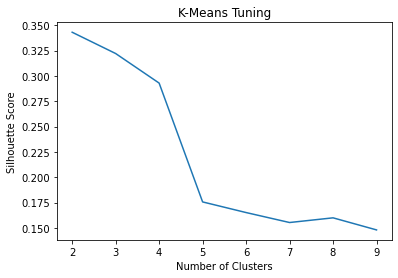

In [7]:
scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_train)
    score = silhouette_score(X_train, labels)
    scores.append(score)

plt.plot(K_range, scores)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("K-Means Tuning")
plt.show()

## 5. Support Vector Machine (SVM)

### Theory
SVM finds a hyperplane maximizing margin:

$$ \min ||w||^2 \quad \text{s.t. } y_i(w^Tx_i + b) \ge 1 $$

### Key Hyperparameters
- C
- kernel
- gamma


Gamma ($\gamma$) is a hyperparameter specifically used with non-linear kernels, most commonly the RBF (Radial Basis Function) or Gaussian kernel.

In the RBF kernel, the similarity between two points $x_i$ and $x_j$ is calculated as:

$$K(x_i, x_j) = \exp(-\gamma ||x_i - x_j||^2)$$

In [9]:
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm = SVC()
grid_svm = GridSearchCV(svm, param_grid_svm, cv=5)
grid_svm.fit(X_train, y_train)

print("Best SVM Params:", grid_svm.best_params_)
y_pred = grid_svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred))

Best SVM Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
SVM Accuracy: 0.9824561403508771


## 6. Neural Network (MLP)

### Theory
A neural network computes:

$$ a^{(l)} = \sigma(W^{(l)} a^{(l-1)} + b^{(l)}) $$

### Key Hyperparameters
- hidden_layer_sizes
- activation
- learning_rate_init

In [11]:
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50,50)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01]
}

mlp = MLPClassifier(max_iter=1000)
grid_mlp = GridSearchCV(mlp, param_grid_mlp, cv=5)
grid_mlp.fit(X_train, y_train)

print("Best MLP Params:", grid_mlp.best_params_)
y_pred = grid_mlp.predict(X_test)
print("MLP Accuracy:", accuracy_score(y_test, y_pred))

Best MLP Params: {'activation': 'relu', 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.001}
MLP Accuracy: 0.9649122807017544


## 7. Decision Tree

### Theory
Decision trees split data using impurity measures such as Gini:

$$ Gini = 1 - \sum p_i^2 $$

### Key Hyperparameters
- max_depth
- min_samples_split

In [12]:
param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

dt = DecisionTreeClassifier(random_state=42)
grid_dt = GridSearchCV(dt, param_grid_dt, cv=5)
grid_dt.fit(X_train, y_train)

print("Best DT Params:", grid_dt.best_params_)
y_pred = grid_dt.predict(X_test)
print("DT Accuracy:", accuracy_score(y_test, y_pred))

Best DT Params: {'max_depth': 3, 'min_samples_split': 2}
DT Accuracy: 0.9473684210526315


## 8. Student Tasks

1. Expand hyperparameter grids for each model.
2. Compare Grid Search vs Random Search.
3. Plot validation curves.
4. Report best models and justify choices.
5. Analyze overfitting vs underfitting.